<a href="https://colab.research.google.com/github/sarahj-creator/taylor-swift-fan-engagement-analysis/blob/main/Taylor_Swift_Fan_Engagement_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

!pip install google-api-python-client pandas matplotlib seaborn textblob


from googleapiclient.discovery import build
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import re

# Your API key
API_KEY = 'YOUR_API_KEY_HERE'

# Build the YouTube service
youtube = build('youtube', 'v3', developerKey=API_KEY)

print("YouTube API connection successful!")


def get_video_comments(video_id, max_results=1000):
    """Collect comments from a YouTube video"""
    comments = []
    
    try:
        # Get video info first
        video_response = youtube.videos().list(
            part='snippet,statistics',
            id=video_id
        ).execute()
        
        video_title = video_response['items'][0]['snippet']['title']
        view_count = video_response['items'][0]['statistics']['viewCount']
        
        print(f"Collecting comments from: {video_title}")
        print(f"Video has {view_count} views")
        
        # Get comments
        request = youtube.commentThreads().list(
            part='snippet',
            videoId=video_id,
            maxResults=min(100, max_results),  # YouTube limits to 100 per request
            order='relevance'  # Get most engaging comments first
        )
        
        while request and len(comments) < max_results:
            response = request.execute()
            
            for item in response['items']:
                comment = item['snippet']['topLevelComment']['snippet']
                comments.append({
                    'author': comment['authorDisplayName'],
                    'text': comment['textDisplay'],
                    'likes': comment['likeCount'],
                    'published': comment['publishedAt'],
                    'reply_count': item['snippet']['totalReplyCount']
                })
            
            # Get next page if available
            request = youtube.commentThreads().list_next(request, response)
            
    except Exception as e:
        print(f"Error: {e}")
    
    print(f"Collected {len(comments)} comments")
    return comments, video_title

# Test with All Too Well (10 Minute Version)
video_id = "tollGa3S0o8"
comments_data, title = get_video_comments(video_id, max_results=500)

# Convert to pandas DataFrame
df = pd.DataFrame(comments_data)
print(f"Dataset shape: {df.shape}")
print("\nFirst few comments:")
df.head()

# Basic stats
print("=== ENGAGEMENT METRICS ===")
print(f"Average likes per comment: {df['likes'].mean():.2f}")
print(f"Average reply count: {df['reply_count'].mean():.2f}")
print(f"Total engagement: {df['likes'].sum() + df['reply_count'].sum()}")

# Most liked comments
print("\n=== TOP 5 MOST LIKED COMMENTS ===")
top_comments = df.nlargest(5, 'likes')[['text', 'likes']]
for idx, row in top_comments.iterrows():
    print(f"❤️ {row['likes']} likes: {row['text'][:100]}...")

# Define lore keywords to search for
lore_keywords = [
    # Other Taylor songs/albums
    'folklore', 'evermore', 'reputation', 'red', 'fearless', 'speak now',
    # Personal references  
    'jake', 'scarf', 'all too well', 'short film', 'sadie',
    # Theory language
    'theory', 'easter egg', 'hidden', 'meaning', 'about',
    # Timeline references
    '13', 'vault', 'version', 'original'
]

def contains_lore(text):
    """Check if comment contains lore-related content"""
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in lore_keywords)

# Add lore indicator
df['has_lore'] = df['text'].apply(contains_lore)

print(f"Comments with lore references: {df['has_lore'].sum()} / {len(df)} ({df['has_lore'].mean()*100:.1f}%)")

# Personal connection keywords
personal_keywords = ['my life', 'saved me', 'crying', 'sobbing', 'feels', 'relate', 'going through']

def contains_personal(text):
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in personal_keywords)

df['is_personal'] = df['text'].apply(contains_personal)

print(f"Personal connection comments: {df['is_personal'].sum()} / {len(df)} ({df['is_personal'].mean()*100:.1f}%)")

# Compare engagement levels
print("\n=== ENGAGEMENT BY COMMENT TYPE ===")
print("Average likes for lore comments:", df[df['has_lore']]['likes'].mean())
print("Average likes for personal comments:", df[df['is_personal']]['likes'].mean())
print("Average likes for other comments:", df[~df['has_lore'] & ~df['is_personal']]['likes'].mean())

# Let's see what lore content is most popular
lore_comments = df[df['has_lore']].nlargest(10, 'likes')[['text', 'likes']]

print("=== TOP LORE COMMENTS ===")
for idx, row in lore_comments.iterrows():
    print(f"\n❤️ {row['likes']} likes:")
    print(f"💬 {row['text'][:200]}...")

# Count mentions of specific lore elements
lore_analysis = {}
for keyword in lore_keywords:
    count = df['text'].str.lower().str.contains(keyword, na=False).sum()
    if count > 0:
        avg_likes = df[df['text'].str.lower().str.contains(keyword, na=False)]['likes'].mean()
        lore_analysis[keyword] = {'mentions': count, 'avg_likes': avg_likes}

print("=== LORE KEYWORD ANALYSIS ===")
for keyword, stats in sorted(lore_analysis.items(), key=lambda x: x[1]['avg_likes'], reverse=True):
    print(f"{keyword}: {stats['mentions']} mentions, {stats['avg_likes']:.0f} avg likes")

# Let's compare this to a non-lore Taylor song
# How about "Shake It Off" - pure pop anthem, minimal narrative
shake_it_off_video_id = "nfWlot6h_JM"  # Shake It Off official video

print("Now collecting 'Shake It Off' comments for comparison...")
shake_comments, shake_title = get_video_comments(shake_it_off_video_id, max_results=500)

# Convert Shake It Off comments to DataFrame
shake_df = pd.DataFrame(shake_comments)

print(f"=== SHAKE IT OFF vs ALL TOO WELL COMPARISON ===")
print(f"Shake It Off views: 3.6 BILLION vs All Too Well: 108 million")
print(f"That's 33x more views!")

# Apply same analysis to Shake It Off
shake_df['has_lore'] = shake_df['text'].apply(contains_lore)
shake_df['is_personal'] = shake_df['text'].apply(contains_personal)

print(f"\n=== LORE ENGAGEMENT COMPARISON ===")
print(f"All Too Well - Lore comments: {df['has_lore'].mean()*100:.1f}%")
print(f"Shake It Off - Lore comments: {shake_df['has_lore'].mean()*100:.1f}%")

print(f"\n=== PERSONAL CONNECTION COMPARISON ===")
print(f"All Too Well - Personal comments: {df['is_personal'].mean()*100:.1f}%")
print(f"Shake It Off - Personal comments: {shake_df['is_personal'].mean()*100:.1f}%")

print(f"\n=== AVERAGE LIKES COMPARISON ===")
print("ALL TOO WELL:")
print(f"  Lore comments: {df[df['has_lore']]['likes'].mean():.0f} avg likes")
print(f"  Personal comments: {df[df['is_personal']]['likes'].mean():.0f} avg likes")
print(f"  Other comments: {df[~df['has_lore'] & ~df['is_personal']]['likes'].mean():.0f} avg likes")

print("\nSHAKE IT OFF:")
print(f"  Lore comments: {shake_df[shake_df['has_lore']]['likes'].mean():.0f} avg likes")
print(f"  Personal comments: {shake_df[shake_df['is_personal']]['likes'].mean():.0f} avg likes")  
print(f"  Other comments: {shake_df[~shake_df['has_lore'] & ~shake_df['is_personal']]['likes'].mean():.0f} avg likes")

# Let's see what people talk about instead of lore
print("=== TOP SHAKE IT OFF COMMENTS ===")
top_shake_comments = shake_df.nlargest(10, 'likes')[['text', 'likes']]
for idx, row in top_shake_comments.iterrows():
    print(f"\n❤️ {row['likes']} likes:")
    print(f"💬 {row['text'][:150]}...")

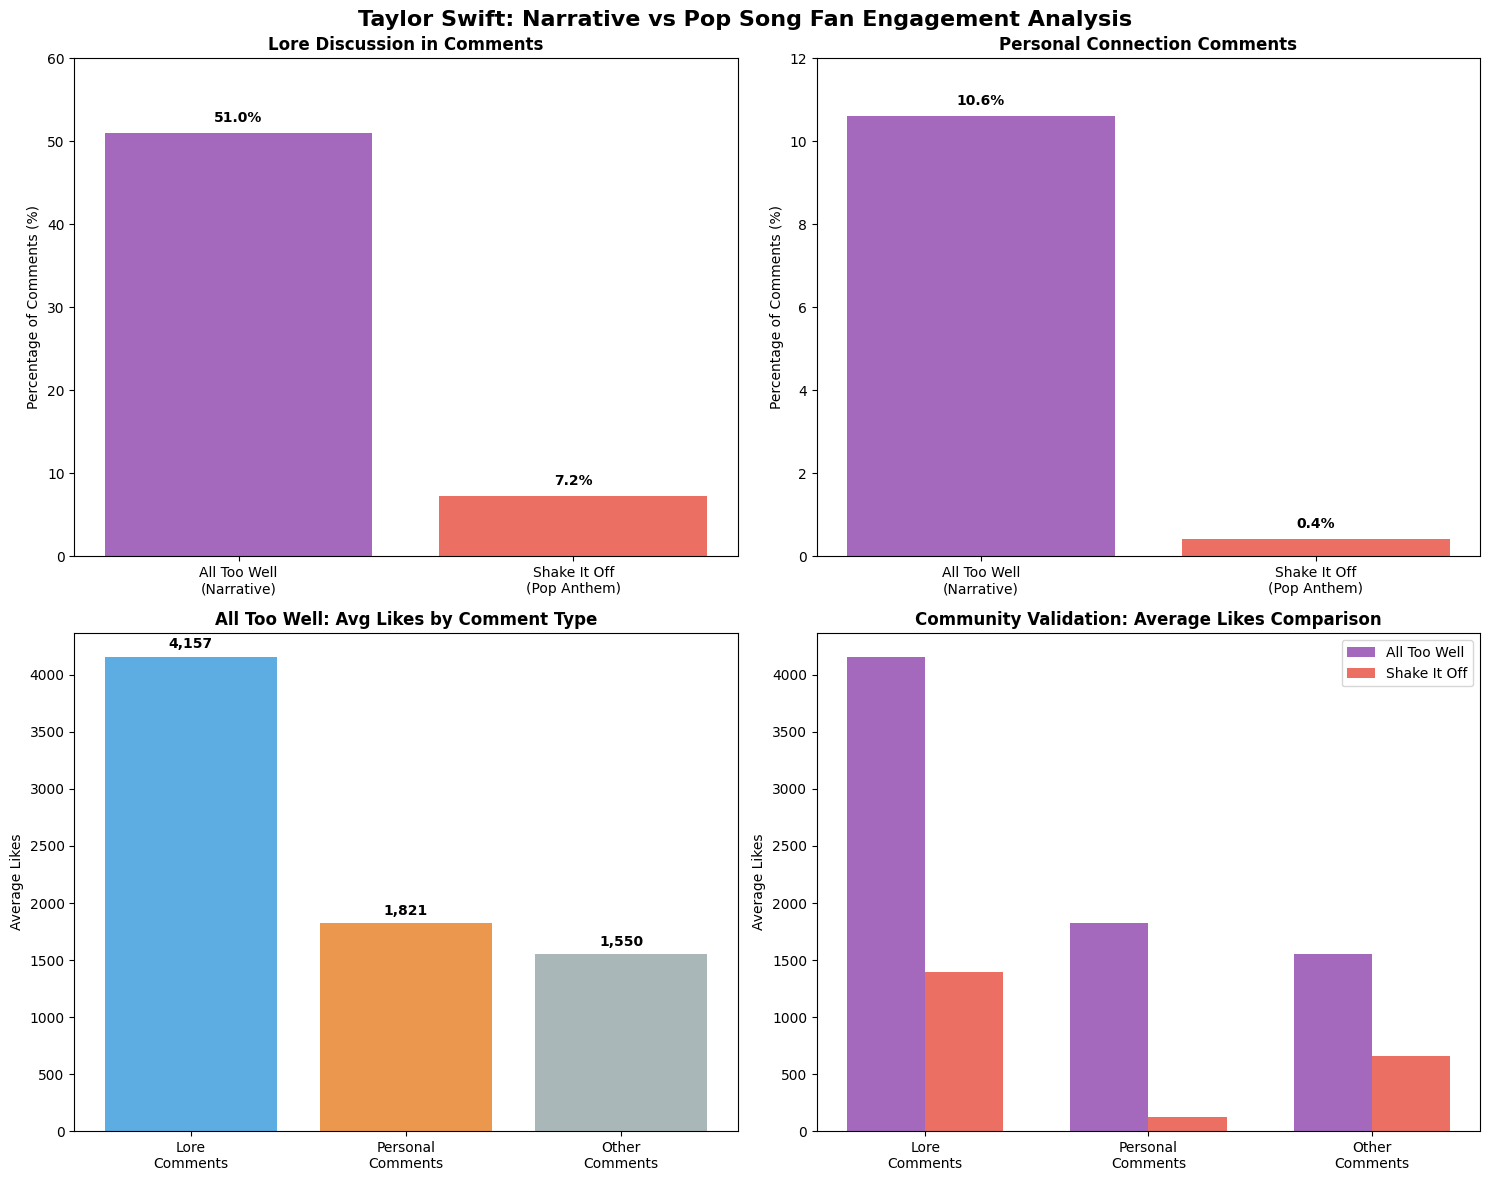

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Taylor Swift: Narrative vs Pop Song Fan Engagement Analysis', fontsize=16, fontweight='bold')

# 1. Lore Engagement Percentage
songs = ['All Too Well\n(Narrative)', 'Shake It Off\n(Pop Anthem)']
lore_percentages = [51.0, 7.2]

bars1 = ax1.bar(songs, lore_percentages, color=['#8E44AD', '#E74C3C'], alpha=0.8)
ax1.set_title('Lore Discussion in Comments', fontweight='bold')
ax1.set_ylabel('Percentage of Comments (%)')
ax1.set_ylim(0, 60)

# Add value labels on bars
for bar, value in zip(bars1, lore_percentages):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}%', ha='center', va='bottom', fontweight='bold')

# 2. Personal Connection Comparison
personal_percentages = [10.6, 0.4]
bars2 = ax2.bar(songs, personal_percentages, color=['#8E44AD', '#E74C3C'], alpha=0.8)
ax2.set_title('Personal Connection Comments', fontweight='bold')
ax2.set_ylabel('Percentage of Comments (%)')
ax2.set_ylim(0, 12)

for bar, value in zip(bars2, personal_percentages):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{value}%', ha='center', va='bottom', fontweight='bold')

# 3. Average Likes by Comment Type (All Too Well)
comment_types = ['Lore\nComments', 'Personal\nComments', 'Other\nComments']
atw_likes = [4157, 1821, 1550]
bars3 = ax3.bar(comment_types, atw_likes, color=['#3498DB', '#E67E22', '#95A5A6'], alpha=0.8)
ax3.set_title('All Too Well: Avg Likes by Comment Type', fontweight='bold')
ax3.set_ylabel('Average Likes')

for bar, value in zip(bars3, atw_likes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{value:,}', ha='center', va='bottom', fontweight='bold')

# 4. Community Validation Comparison
x = np.arange(len(comment_types))
width = 0.35

atw_data = [4157, 1821, 1550]
sio_data = [1391, 125, 659]

bars4a = ax4.bar(x - width/2, atw_data, width, label='All Too Well', color='#8E44AD', alpha=0.8)
bars4b = ax4.bar(x + width/2, sio_data, width, label='Shake It Off', color='#E74C3C', alpha=0.8)

ax4.set_title('Community Validation: Average Likes Comparison', fontweight='bold')
ax4.set_ylabel('Average Likes')
ax4.set_xticks(x)
ax4.set_xticklabels(comment_types)
ax4.legend()

plt.tight_layout()
plt.show()